## Test dataset

Esta libreta se creo para verificar cómo venían los datos del dataset

In [16]:
import random
from pathlib import Path

import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
import torchvision.transforms.functional as F


class SUNNYUFolderDataset(Dataset):
    """
    Dataset para la estructura tipo SUNRGBD/NYU:

      root/
        ├── b3dodata/img_0063/
        │     ├── image/img_0063.jpg
        │     ├── depth_bfx/img_0063_abs.png
        │     └── ...
        ├── NYUdata/NYU0010/
              ├── image/NYU0010.jpg
              ├── depth_bfx/NYU0010.png
              └── ...

    Usa:
      - RGB  : image/*.jpg
      - Depth: depth_bfx/*.png  (o depth/*.png si no existe depth_bfx)

    Devuelve:
      - rgb:   [3, 224, 224] float32 en [0,1]
      - depth: [1, 224, 224] float32 en metros
      - index: índice global dentro del split
    """

    def __init__(
        self,
        root_dir,
        resize=(224, 224),
        split="train",
        split_file=None,
        val_ratio=0.15,
        test_ratio=0.15,
        seed=1337,
        augment=True,
    ):
        super().__init__()
        self.root_dir = Path(root_dir)
        if not self.root_dir.exists():
            raise FileNotFoundError(f"No se encontró el directorio raíz: {self.root_dir}")

        if split not in ("train", "val", "test"):
            raise ValueError(f"split debe ser 'train', 'val' o 'test', no '{split}'")

        self.resize = resize
        self.depth_size = resize
        self.split = split
        self.augment = augment and (split == "train")  # solo train se augumenta

        # Transform base para RGB cuando NO hay augment
        self.rgb_transform = T.Compose([
            T.Resize(self.resize, interpolation=T.InterpolationMode.BILINEAR),
            T.ToTensor(),  # [3,H,W] en [0,1]
        ])

        # Color jitter solo para RGB (se aplica dentro de __getitem__)
        self.color_jitter = T.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2,
            hue=0.05,
        )

        # Descubrimos muestras
        if split_file is not None:
            self.samples = self._load_from_split_file(split_file)
        else:
            all_samples = self._discover_all_samples()
            self.samples = self._make_split(
                all_samples,
                split=split,
                val_ratio=val_ratio,
                test_ratio=test_ratio,
                seed=seed,
            )

    # ------------------------------------------------------------------ #
    # Descubrimiento de escenas
    # ------------------------------------------------------------------ #

    def _discover_all_samples(self):
        samples = []

        image_dirs = list(self.root_dir.rglob("image"))
        for img_dir in image_dirs:
            jpgs = sorted(img_dir.glob("*.jpg"))
            if len(jpgs) == 0:
                continue

            scene_dir = img_dir.parent

            depth_bfx_dir = scene_dir / "depth_bfx"
            depth_dir = scene_dir / "depth"

            depth_path = None
            if depth_bfx_dir.exists():
                pngs = sorted(depth_bfx_dir.glob("*.png"))
                if len(pngs) > 0:
                    depth_path = pngs[0]
            if depth_path is None and depth_dir.exists():
                pngs = sorted(depth_dir.glob("*.png"))
                if len(pngs) > 0:
                    depth_path = pngs[0]

            if depth_path is None:
                continue

            rgb_path = jpgs[0]

            samples.append({
                "scene_dir": scene_dir,
                "rgb_path": rgb_path,
                "depth_path": depth_path,
            })

        if len(samples) == 0:
            raise RuntimeError(
                f"No se encontraron escenas con image/*.jpg y depth[_bfx]/*.png en {self.root_dir}"
            )

        samples = sorted(samples, key=lambda s: str(s["rgb_path"]))
        return samples

    # ------------------------------------------------------------------ #
    # Splits
    # ------------------------------------------------------------------ #

    def _make_split(self, all_samples, split, val_ratio, test_ratio, seed):
        n = len(all_samples)
        if not (0.0 < val_ratio < 1.0 and 0.0 < test_ratio < 1.0 and val_ratio + test_ratio < 1.0):
            raise ValueError("val_ratio y test_ratio deben ser >0 y val+test<1")

        indices = list(range(n))
        rng = random.Random(seed)
        rng.shuffle(indices)

        n_val = int(round(n * val_ratio))
        n_test = int(round(n * test_ratio))
        n_train = n - n_val - n_test

        train_idx = indices[:n_train]
        val_idx = indices[n_train:n_train + n_val]
        test_idx = indices[n_train + n_val:]

        if split == "train":
            chosen = [all_samples[i] for i in train_idx]
        elif split == "val":
            chosen = [all_samples[i] for i in val_idx]
        else:
            chosen = [all_samples[i] for i in test_idx]

        return chosen

    def _load_from_split_file(self, split_file):
        split_path = Path(split_file)
        if not split_path.exists():
            raise FileNotFoundError(f"No se encontró split_file: {split_path}")

        samples = []
        with split_path.open("r") as f:
            for line in f:
                rel = line.strip()
                if not rel:
                    continue
                scene_dir = (self.root_dir / rel).resolve()
                img_dir = scene_dir / "image"
                depth_bfx_dir = scene_dir / "depth_bfx"
                depth_dir = scene_dir / "depth"

                jpgs = sorted(img_dir.glob("*.jpg"))
                if len(jpgs) == 0:
                    continue
                rgb_path = jpgs[0]

                depth_path = None
                if depth_bfx_dir.exists():
                    pngs = sorted(depth_bfx_dir.glob("*.png"))
                    if len(pngs) > 0:
                        depth_path = pngs[0]
                if depth_path is None and depth_dir.exists():
                    pngs = sorted(depth_dir.glob("*.png"))
                    if len(pngs) > 0:
                        depth_path = pngs[0]

                if depth_path is None:
                    continue

                samples.append({
                    "scene_dir": scene_dir,
                    "rgb_path": rgb_path,
                    "depth_path": depth_path,
                })

        if len(samples) == 0:
            raise RuntimeError(
                f"No se encontraron escenas válidas a partir de {split_file}"
            )

        return samples

    # ------------------------------------------------------------------ #
    # Dataset API
    # ------------------------------------------------------------------ #

    def __len__(self):
        return len(self.samples)

    def _augment_pair(self, img_pil, depth_m):
        """
        Aplica las mismas transf geométricas a RGB y depth.
        depth_m: np.array float32 en metros.
        Devuelve img_tensor [3,224,224], depth_tensor [1,224,224].
        """
        # depth_m -> PIL modo 'F'
        depth_pil = Image.fromarray(depth_m)

        # 1) Random horizontal flip
        if random.random() < 0.5:
            img_pil = F.hflip(img_pil)
            depth_pil = F.hflip(depth_pil)

        # 2) Random Resized Crop (como RandomResizedCrop)
        scale = (0.8, 1.0)      # rango de escala de área
        ratio = (0.9, 1.1)      # ligera variación de aspecto

        i, j, h, w = T.RandomResizedCrop.get_params(img_pil, scale=scale, ratio=ratio)

        img_pil = F.resized_crop(
            img_pil, i, j, h, w, self.resize,
            interpolation=T.InterpolationMode.BILINEAR
        )
        depth_pil = F.resized_crop(
            depth_pil, i, j, h, w, self.resize,
            interpolation=T.InterpolationMode.NEAREST
        )

        # 3) Color jitter solo para RGB
        img_pil = self.color_jitter(img_pil)

        # 4) A tensor
        rgb = F.to_tensor(img_pil)          # [3,224,224] en [0,1]
        depth_resized = np.array(depth_pil, dtype=np.float32)
        depth = torch.from_numpy(depth_resized).unsqueeze(0)  # [1,224,224]

        return rgb, depth

    def __getitem__(self, idx):
        item = self.samples[idx]
        rgb_path = item["rgb_path"]
        depth_path = item["depth_path"]

        # ---------- RGB ----------
        img_pil = Image.open(rgb_path).convert("RGB")

        # ---------- Depth ----------
        depth_pil_raw = Image.open(depth_path)
        depth_np_raw = np.array(depth_pil_raw, dtype=np.uint16)    # [H,W]
        depth_m = depth_np_raw.astype(np.float32) / 10000.0        # -> metros

        if self.augment:
            rgb, depth = self._augment_pair(img_pil, depth_m)
        else:
            # Sin augment: sólo resize consistente
            rgb = self.rgb_transform(img_pil)  # [3,224,224]

            depth_pil = Image.fromarray(depth_m)
            depth_pil = depth_pil.resize(self.depth_size, resample=Image.NEAREST)
            depth_resized = np.array(depth_pil, dtype=np.float32)
            depth = torch.from_numpy(depth_resized).unsqueeze(0)   # [1,224,224]

        sample = {
            "rgb": rgb,
            "depth": depth,
            "index": idx,
        }
        return sample


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import random
from PIL import Image

def visualize_sample(sample, dataset=None, figsize=(15, 5), show_info=True):
    """
    Visualiza una muestra del dataset SUNNYUFolderDataset.
    
    Args:
        sample: dict con 'rgb', 'depth', 'index' (output del dataset)
        dataset: instancia del dataset (opcional, para obtener paths)
        figsize: tamaño de la figura
        show_info: mostrar información adicional
    """
    rgb = sample['rgb']
    depth = sample['depth']
    idx = sample.get('index', 0)
    
    # Convertir tensores a numpy para matplotlib
    rgb_np = rgb.numpy() if isinstance(rgb, torch.Tensor) else rgb
    depth_np = depth.numpy() if isinstance(depth, torch.Tensor) else depth
    
    # No desnormalizar ya que tu dataset devuelve RGB en [0,1]
    # Solo transponer para formato HWC
    rgb_np = np.transpose(rgb_np, (1, 2, 0))
    depth_np = depth_np.squeeze()  # [H, W]
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # RGB
    axes[0].imshow(rgb_np)
    axes[0].set_title(f"RGB Image (Sample {idx})")
    axes[0].axis('off')
    
    # Depth - usar colormap adecuado
    depth_plot = axes[1].imshow(depth_np, cmap='jet', vmin=0, vmax=depth_np.max())
    axes[1].set_title(f"Depth Map\nmax: {depth_np.max():.2f}m, min: {depth_np.min():.2f}m")
    axes[1].axis('off')
    plt.colorbar(depth_plot, ax=axes[1], fraction=0.046, pad=0.04)
    
    # Depth en escala logarítmica para mejor visualización
    depth_log = np.log1p(depth_np)
    axes[2].imshow(depth_log, cmap='jet')
    axes[2].set_title("Depth (log scale)")
    axes[2].axis('off')
    plt.colorbar(axes[2].imshow(depth_log, cmap='jet'), ax=axes[2], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()
    
    if show_info:
        # Estadísticas
        print(f"\n=== Estadísticas de la muestra {idx} ===")
        print(f"RGB shape: {rgb.shape}, range: [{rgb_np.min():.3f}, {rgb_np.max():.3f}]")
        print(f"Depth shape: {depth.shape}")
        print(f"Depth range: [{depth_np.min():.3f}, {depth_np.max():.3f}] m")
        print(f"Depth mean: {depth_np.mean():.3f} m, std: {depth_np.std():.3f} m")
        
        if dataset is not None and idx < len(dataset.samples):
            item = dataset.samples[idx]
            print(f"\nPaths:")
            print(f"  RGB: {item['rgb_path']}")
            print(f"  Depth: {item['depth_path']}")
            print(f"  Scene: {item['scene_dir'].name}")

In [17]:
def visualize_dataset_grid(dataset, num_samples=6, indices=None, figsize=(20, 10)):
    """
    Visualiza varias muestras del dataset en una cuadrícula.
    
    Args:
        dataset: instancia de SUNNYUFolderDataset
        num_samples: número de muestras a visualizar
        indices: lista específica de índices (opcional)
        figsize: tamaño de la figura
    """
    if indices is None:
        indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))
    else:
        num_samples = len(indices)
    
    rows = 2  # Dos filas: RGB y Depth
    cols = num_samples
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if cols == 1:
        axes = axes.reshape(rows, 1)
    
    for i, idx in enumerate(indices):
        sample = dataset[idx]
        rgb = sample['rgb']
        depth = sample['depth']
        
        # Convertir a numpy
        rgb_np = rgb.numpy()
        depth_np = depth.numpy().squeeze()
        
        # Transponer RGB
        rgb_np = np.transpose(rgb_np, (1, 2, 0))
        
        # RGB (fila superior)
        axes[0, i].imshow(rgb_np)
        axes[0, i].set_title(f"Sample {idx}", fontsize=10)
        axes[0, i].axis('off')
        
        # Depth (fila inferior)
        im = axes[1, i].imshow(depth_np, cmap='jet', vmin=0, vmax=10)
        axes[1, i].set_title(f"Depth: {depth_np.max():.1f}m", fontsize=10)
        axes[1, i].axis('off')
    
    plt.suptitle(f"Visualización de {num_samples} muestras del dataset ({dataset.split} split)", fontsize=14)
    plt.tight_layout()
    plt.show()

In [18]:
def visualize_overlay(rgb, depth, alpha=0.6, figsize=(10, 8)):
    """
    Visualiza RGB y Depth superpuestos.
    
    Args:
        rgb: tensor RGB [3, H, W]
        depth: tensor Depth [1, H, W]
        alpha: transparencia del overlay
        figsize: tamaño de la figura
    """
    # Convertir a numpy
    rgb_np = rgb.numpy() if isinstance(rgb, torch.Tensor) else rgb
    depth_np = depth.numpy() if isinstance(depth, torch.Tensor) else depth
    
    # Desnormalizar RGB
    if rgb_np.min() < 0:
        mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
        std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
        rgb_np = rgb_np * std + mean
        rgb_np = np.clip(rgb_np, 0, 1)
    
    rgb_np = np.transpose(rgb_np, (1, 2, 0))
    depth_np = depth_np.squeeze()
    
    # Normalizar depth para colormap
    depth_normalized = (depth_np - depth_np.min()) / (depth_np.max() - depth_np.min() + 1e-8)
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    # 1. RGB solo
    axes[0, 0].imshow(rgb_np)
    axes[0, 0].set_title("RGB")
    axes[0, 0].axis('off')
    
    # 2. Depth solo
    im1 = axes[0, 1].imshow(depth_np, cmap='jet')
    axes[0, 1].set_title(f"Depth ({depth_np.min():.2f}-{depth_np.max():.2f}m)")
    axes[0, 1].axis('off')
    plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)
    
    # 3. Depth como overlay sobre RGB
    axes[1, 0].imshow(rgb_np)
    im2 = axes[1, 0].imshow(depth_normalized, cmap='jet', alpha=alpha)
    axes[1, 0].set_title("RGB + Depth Overlay")
    axes[1, 0].axis('off')
    
    # 4. Histograma de profundidad
    axes[1, 1].hist(depth_np.flatten(), bins=50, log=True)
    axes[1, 1].set_title("Depth Histogram")
    axes[1, 1].set_xlabel("Depth (m)")
    axes[1, 1].set_ylabel("Frequency (log)")
    
    plt.tight_layout()
    plt.show()

In [19]:
def visualize_rgbd_overlay(sample, alpha=0.6, figsize=(12, 4)):
    """
    Visualiza RGB y Depth superpuestos.
    
    Args:
        sample: dict con 'rgb' y 'depth'
        alpha: transparencia del overlay
        figsize: tamaño de la figura
    """
    rgb = sample['rgb']
    depth = sample['depth']
    
    # Convertir a numpy
    rgb_np = rgb.numpy()
    depth_np = depth.numpy().squeeze()
    
    rgb_np = np.transpose(rgb_np, (1, 2, 0))
    
    # Normalizar depth para colormap
    depth_normalized = (depth_np - depth_np.min()) / (depth_np.max() - depth_np.min() + 1e-8)
    
    # Crear overlay
    from matplotlib.colors import ListedColormap
    jet_cmap = plt.cm.jet
    depth_colored = jet_cmap(depth_normalized)[:, :, :3]  # Solo RGB, sin alpha
    
    overlay = rgb_np * (1 - alpha) + depth_colored * alpha
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # 1. RGB solo
    axes[0].imshow(rgb_np)
    axes[0].set_title("RGB")
    axes[0].axis('off')
    
    # 2. Depth solo
    im1 = axes[1].imshow(depth_np, cmap='jet', vmin=0, vmax=depth_np.max())
    axes[1].set_title(f"Depth Map\n({depth_np.min():.2f}-{depth_np.max():.2f}m)")
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    
    # 3. Overlay
    axes[2].imshow(overlay)
    axes[2].set_title(f"RGB + Depth Overlay (α={alpha})")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

In [20]:
def visualize_augmentation_comparison(dataset, idx=None, num_pairs=3, figsize=(15, 10)):
    """
    Compara muestras originales vs aumentadas (solo para train split).
    
    Args:
        dataset: instancia de SUNNYUFolderDataset (debe tener augment=True)
        idx: índice específico (opcional)
        num_pairs: número de pares a mostrar
        figsize: tamaño de la figura
    """
    if dataset.split != 'train' or not dataset.augment:
        print("⚠️  Dataset no está en modo augmentación (split='train', augment=True)")
        return
    
    if idx is None:
        indices = random.sample(range(len(dataset)), min(num_pairs, len(dataset)))
    else:
        indices = [idx] if isinstance(idx, int) else idx[:num_pairs]
    
    rows = len(indices)
    fig, axes = plt.subplots(rows, 4, figsize=figsize)
    if rows == 1:
        axes = axes.reshape(1, 4)
    
    for i, idx in enumerate(indices):
        item = dataset.samples[idx]
        
        # Cargar original (sin augment)
        img_pil = Image.open(item["rgb_path"]).convert("RGB")
        depth_pil = Image.open(item["depth_path"])
        depth_np = np.array(depth_pil, dtype=np.uint16).astype(np.float32) / 10000.0
        
        # Crear versión original (resize sin augment)
        rgb_original = dataset.rgb_transform(img_pil)
        depth_pil_resized = Image.fromarray(depth_np).resize(dataset.depth_size, Image.NEAREST)
        depth_original = torch.from_numpy(np.array(depth_pil_resized, dtype=np.float32)).unsqueeze(0)
        
        # Obtener versión aumentada (con __getitem__)
        sample_aug = dataset[idx]
        rgb_aug = sample_aug['rgb']
        depth_aug = sample_aug['depth']
        
        # Convertir a numpy para visualizar
        rgb_orig_np = np.transpose(rgb_original.numpy(), (1, 2, 0))
        depth_orig_np = depth_original.numpy().squeeze()
        rgb_aug_np = np.transpose(rgb_aug.numpy(), (1, 2, 0))
        depth_aug_np = depth_aug.numpy().squeeze()
        
        # Original RGB
        axes[i, 0].imshow(rgb_orig_np)
        if i == 0:
            axes[i, 0].set_title("Original RGB")
        axes[i, 0].axis('off')
        
        # Original Depth
        axes[i, 1].imshow(depth_orig_np, cmap='jet', vmin=0, vmax=10)
        if i == 0:
            axes[i, 1].set_title("Original Depth")
        axes[i, 1].axis('off')
        
        # Augmented RGB
        axes[i, 2].imshow(rgb_aug_np)
        if i == 0:
            axes[i, 2].set_title("Augmented RGB")
        axes[i, 2].axis('off')
        
        # Augmented Depth
        axes[i, 3].imshow(depth_aug_np, cmap='jet', vmin=0, vmax=10)
        if i == 0:
            axes[i, 3].set_title("Augmented Depth")
        axes[i, 3].axis('off')
    
    plt.suptitle("Comparación: Original vs Aumentado", fontsize=14)
    plt.tight_layout()
    plt.show()

In [21]:
def visualize_dataset_stats(dataset, max_samples=1000, num_bins=50):
    """
    Muestra estadísticas de profundidad del dataset.
    
    Args:
        dataset: instancia del dataset
        max_samples: máximo de muestras a procesar (para datasets grandes)
        num_bins: número de bins para histogramas
    """
    print(f"Analizando estadísticas del dataset ({dataset.split} split)...")
    
    depths = []
    rgb_values = {'R': [], 'G': [], 'B': []}
    
    num_to_process = min(len(dataset), max_samples)
    step = max(1, len(dataset) // num_to_process)
    
    for i in range(0, len(dataset), step):
        if len(depths) >= max_samples:
            break
            
        sample = dataset[i]
        depth = sample['depth']
        rgb = sample['rgb']
        
        # Profundidades válidas (>0)
        depth_np = depth.numpy().flatten()
        valid_depth = depth_np[depth_np > 0]
        depths.extend(valid_depth)
        
        # Valores RGB
        rgb_np = rgb.numpy()
        rgb_values['R'].extend(rgb_np[0].flatten())
        rgb_values['G'].extend(rgb_np[1].flatten())
        rgb_values['B'].extend(rgb_np[2].flatten())
        
        if i % 500 == 0:
            print(f"  Procesado {i}/{len(dataset)} muestras...")
    
    depths = np.array(depths)
    
    # Crear figura
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # 1. Histograma de profundidades
    axes[0, 0].hist(depths, bins=num_bins, log=True, alpha=0.7, color='blue')
    axes[0, 0].set_title(f"Depth Distribution\n(n={len(depths):,} valid pixels)")
    axes[0, 0].set_xlabel("Depth (m)")
    axes[0, 0].set_ylabel("Frequency (log)")
    axes[0, 0].axvline(np.mean(depths), color='r', linestyle='--', 
                      label=f'Mean: {np.mean(depths):.2f}m')
    axes[0, 0].axvline(np.median(depths), color='g', linestyle='--', 
                      label=f'Median: {np.median(depths):.2f}m')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Box plot de profundidades
    axes[0, 1].boxplot(depths[::100] if len(depths) > 100 else depths, vert=False)
    axes[0, 1].set_title("Depth Box Plot")
    axes[0, 1].set_xlabel("Depth (m)")
    
    # 3. CDF de profundidades
    sorted_depths = np.sort(depths)
    cdf = np.arange(1, len(sorted_depths) + 1) / len(sorted_depths)
    axes[0, 2].plot(sorted_depths, cdf)
    axes[0, 2].set_title("Depth Cumulative Distribution")
    axes[0, 2].set_xlabel("Depth (m)")
    axes[0, 2].set_ylabel("CDF")
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Distribución de canales RGB
    for i, channel in enumerate(['R', 'G', 'B']):
        values = np.array(rgb_values[channel])
        axes[1, i].hist(values, bins=50, alpha=0.7, 
                       color=channel.lower(), density=True)
        axes[1, i].set_title(f"{channel} Channel Distribution")
        axes[1, i].set_xlabel("Intensity")
        axes[1, i].set_ylabel("Density")
        axes[1, i].axvline(np.mean(values), color='black', linestyle='--', 
                          label=f'Mean: {np.mean(values):.3f}')
        axes[1, i].legend()
        axes[1, i].grid(True, alpha=0.3)
    
    plt.suptitle(f"Dataset Statistics - {dataset.split} split ({len(dataset)} samples)", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Estadísticas numéricas
    print("\n" + "="*50)
    print(f"ESTADÍSTICAS DEL DATASET ({dataset.split.upper()})")
    print("="*50)
    print(f"Número de muestras: {len(dataset)}")
    print(f"Píxeles válidos analizados: {len(depths):,}")
    print(f"\nProfundidad:")
    print(f"  Min: {depths.min():.3f} m")
    print(f"  Max: {depths.max():.3f} m")
    print(f"  Mean: {depths.mean():.3f} ± {depths.std():.3f} m")
    print(f"  Median: {np.median(depths):.3f} m")
    print(f"  25th percentile: {np.percentile(depths, 25):.3f} m")
    print(f"  75th percentile: {np.percentile(depths, 75):.3f} m")
    print(f"  90th percentile: {np.percentile(depths, 90):.3f} m")
    
    print(f"\nRGB (rango [0, 1]):")
    for channel in ['R', 'G', 'B']:
        values = np.array(rgb_values[channel])
        print(f"  {channel}: mean={values.mean():.3f}, std={values.std():.3f}, "
              f"min={values.min():.3f}, max={values.max():.3f}")

PROBANDO VISUALIZACIONES CON SUNNYUFolderDataset
Dataset: SUNRGBD/kv1
Split: train, Augment: True
✓ Dataset creado: 1403 muestras en split 'train'

1. VISUALIZANDO MUESTRA ALEATORIA (índice 674):


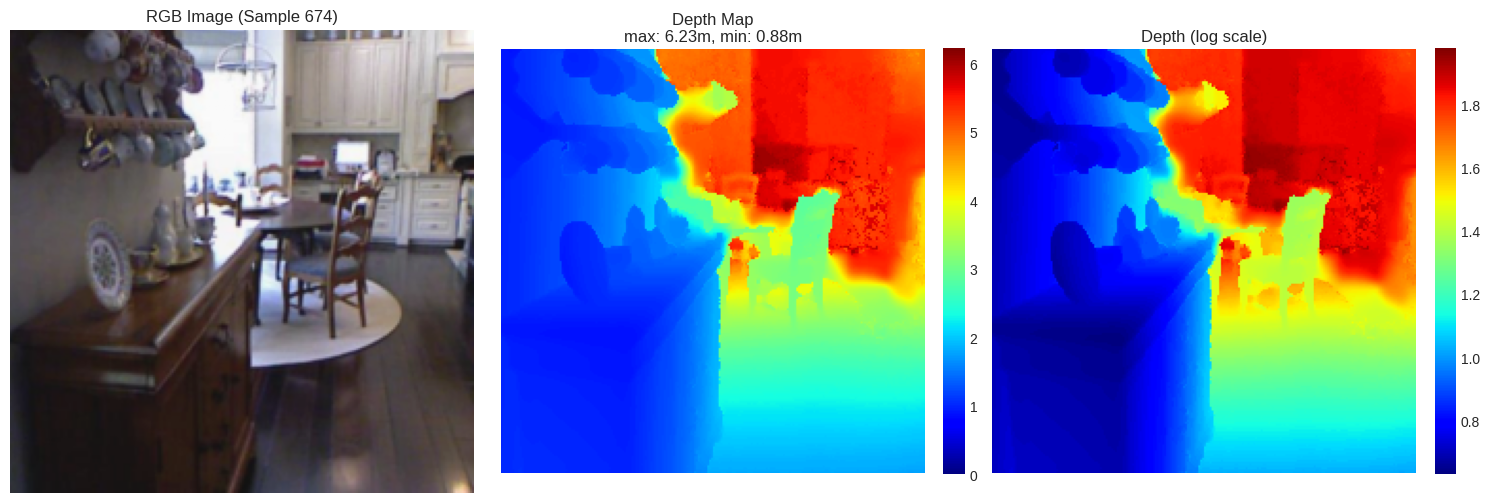


=== Estadísticas de la muestra 674 ===
RGB shape: torch.Size([3, 224, 224]), range: [0.067, 0.984]
Depth shape: torch.Size([1, 224, 224])
Depth range: [0.876, 6.226] m
Depth mean: 2.673 m, std: 1.695 m

Paths:
  RGB: SUNRGBD/kv1/NYUdata/NYU0745/image/NYU0745.jpg
  Depth: SUNRGBD/kv1/NYUdata/NYU0745/depth_bfx/NYU0745.png
  Scene: NYU0745

2. VISUALIZACIÓN CON OVERLAY RGB-DEPTH:


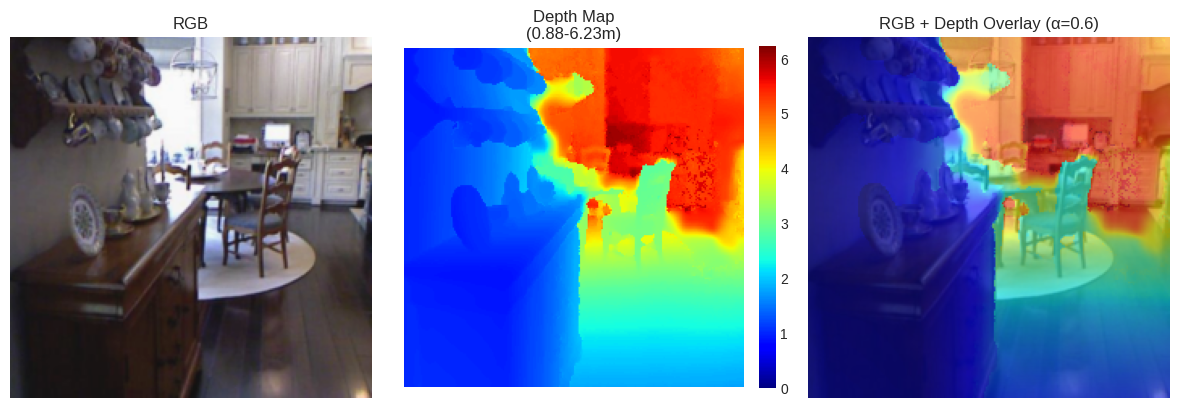


3. VISUALIZANDO 6 MUESTRAS ALEATORIAS:


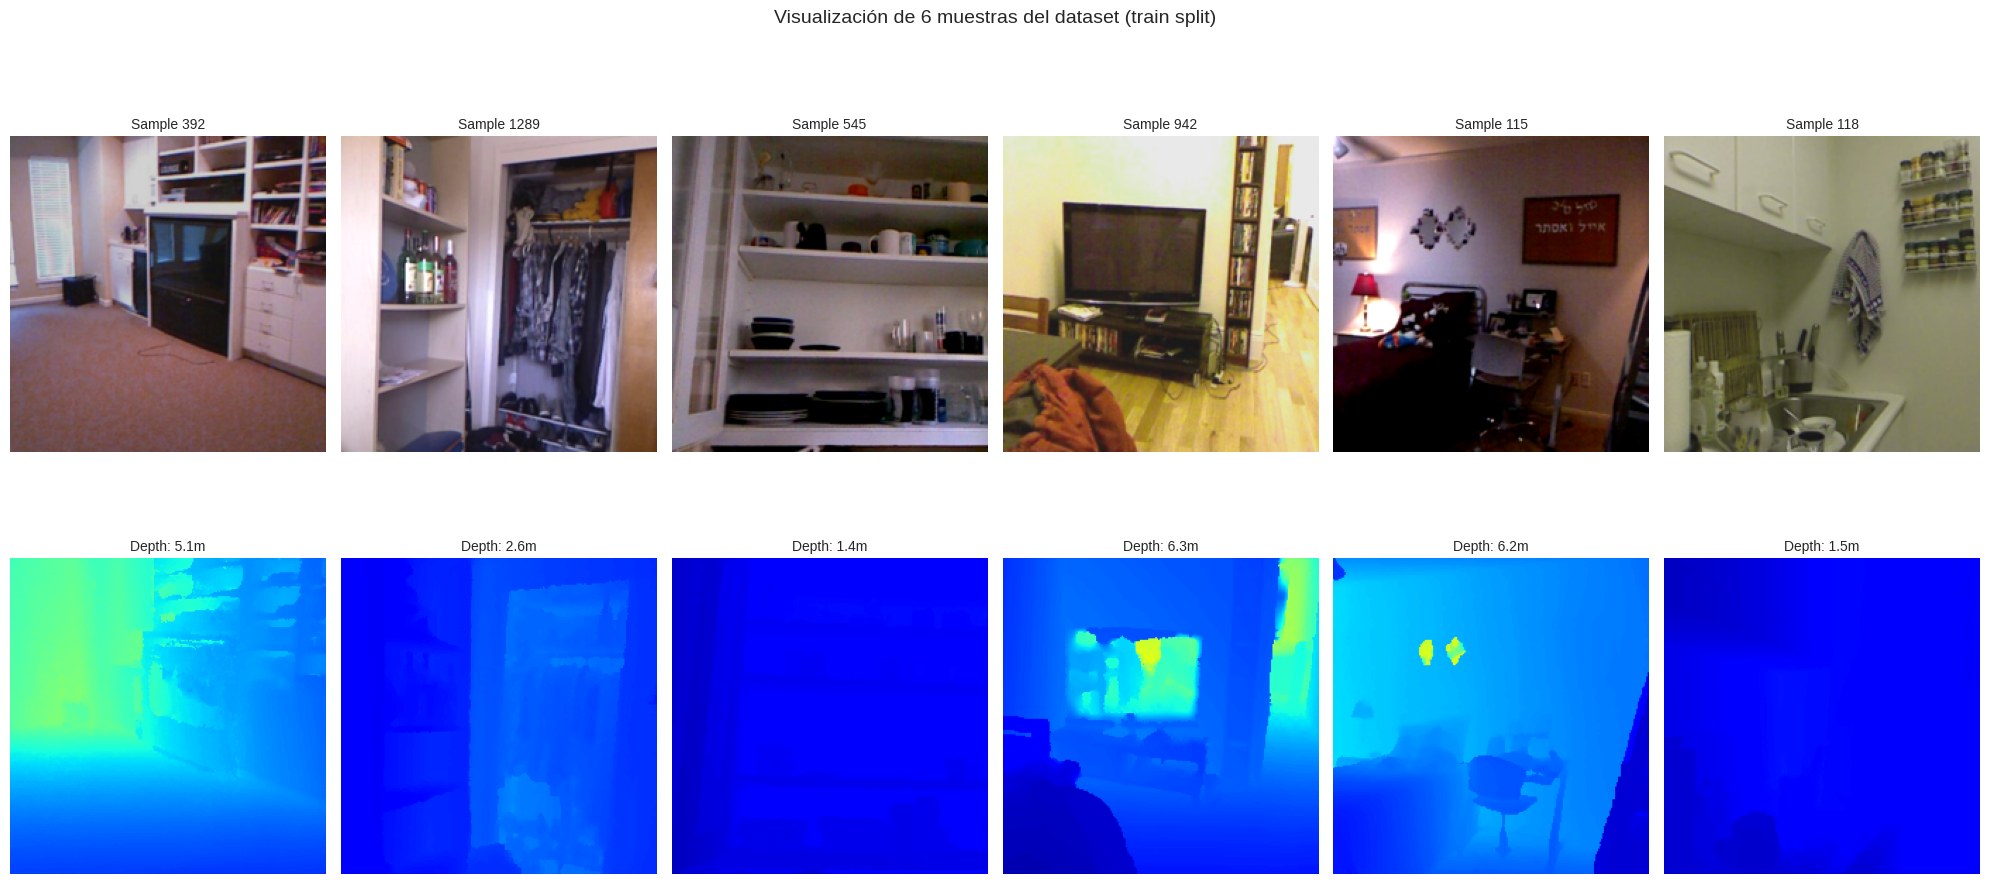


4. COMPARACIÓN DE AUGMENTACIONES:


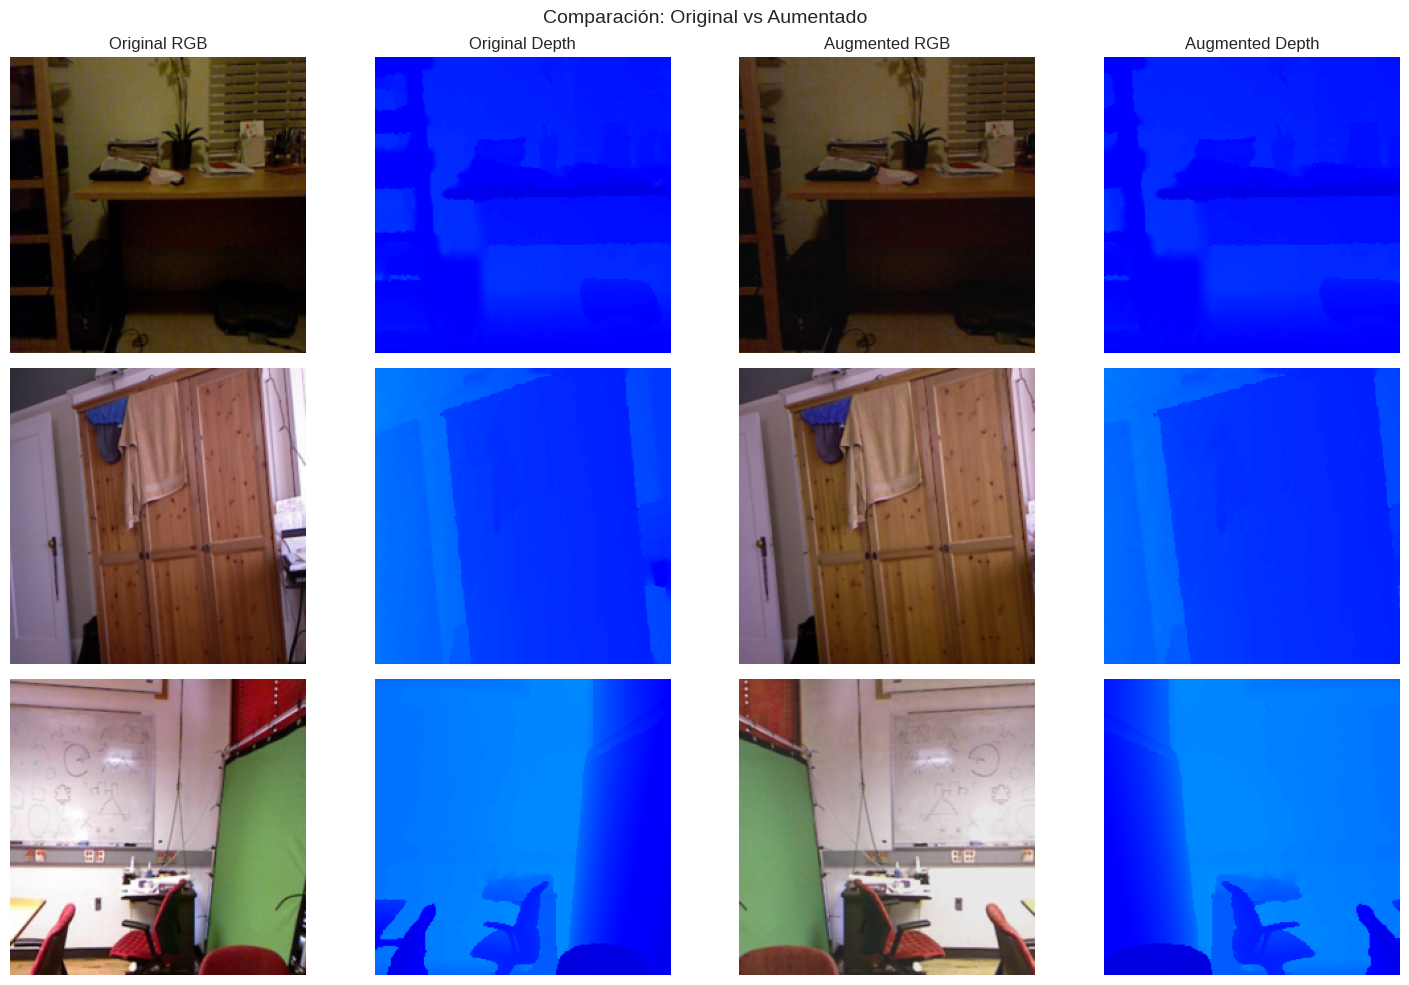


5. ESTADÍSTICAS DEL DATASET:
Analizando estadísticas del dataset (train split)...
  Procesado 0/1403 muestras...


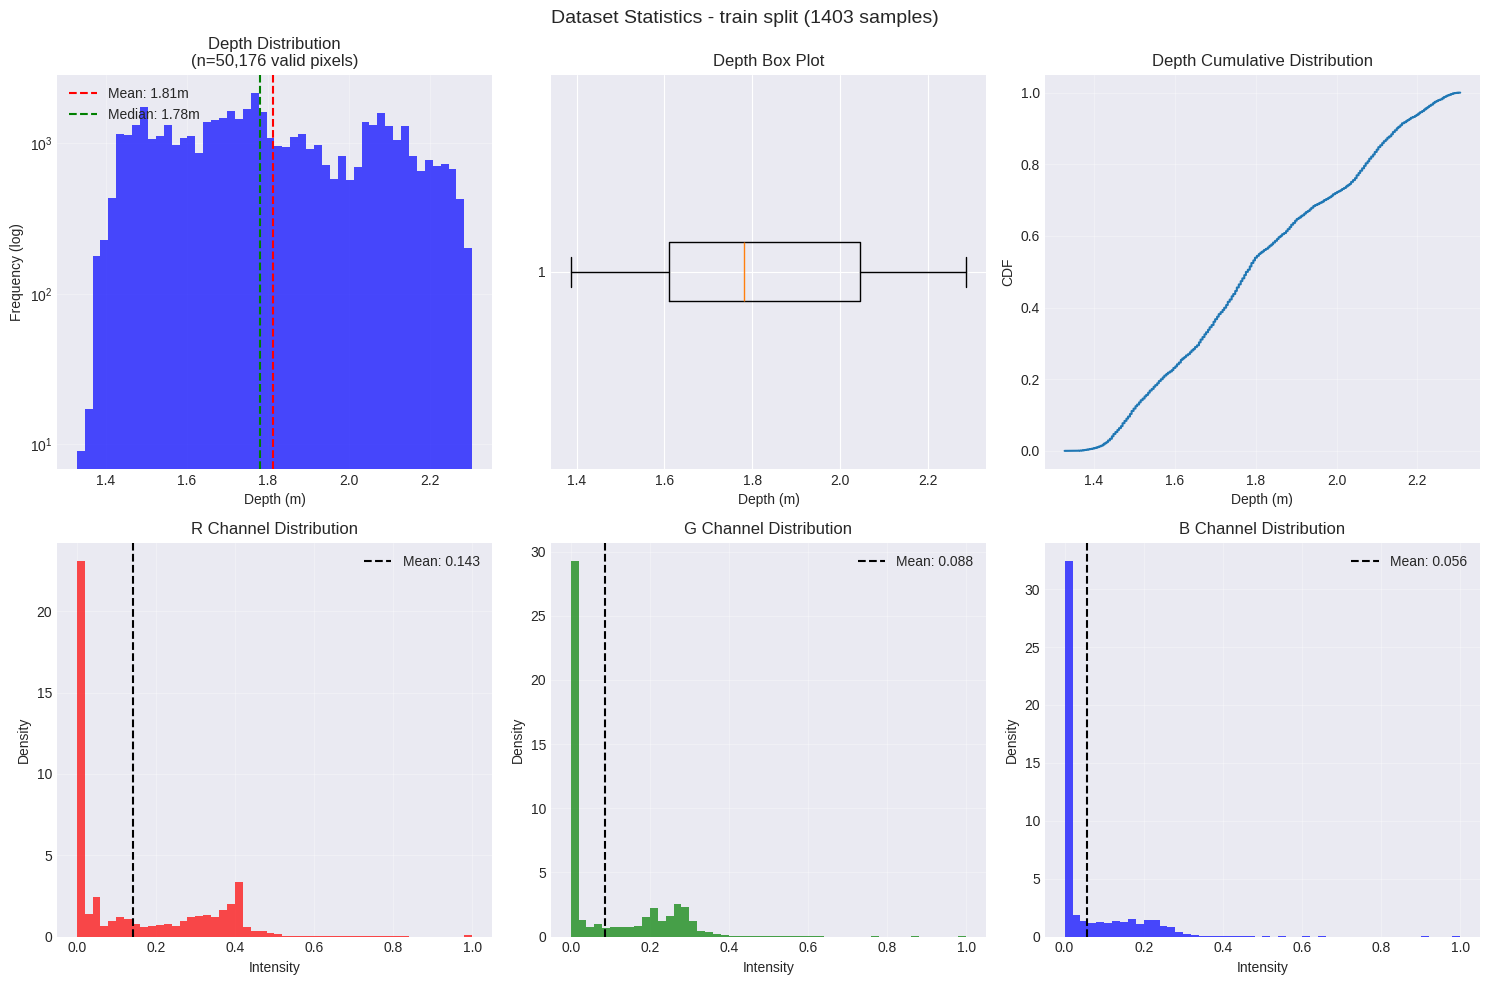


ESTADÍSTICAS DEL DATASET (TRAIN)
Número de muestras: 1403
Píxeles válidos analizados: 50,176

Profundidad:
  Min: 1.328 m
  Max: 2.306 m
  Mean: 1.812 ± 0.242 m
  Median: 1.781 m
  25th percentile: 1.615 m
  75th percentile: 2.036 m
  90th percentile: 2.149 m

RGB (rango [0, 1]):
  R: mean=0.143, std=0.170, min=0.000, max=1.000
  G: mean=0.088, std=0.124, min=0.000, max=1.000
  B: mean=0.056, std=0.096, min=0.000, max=1.000

PROBANDO SPLIT DE VALIDACIÓN
Dataset de validación: 300 muestras


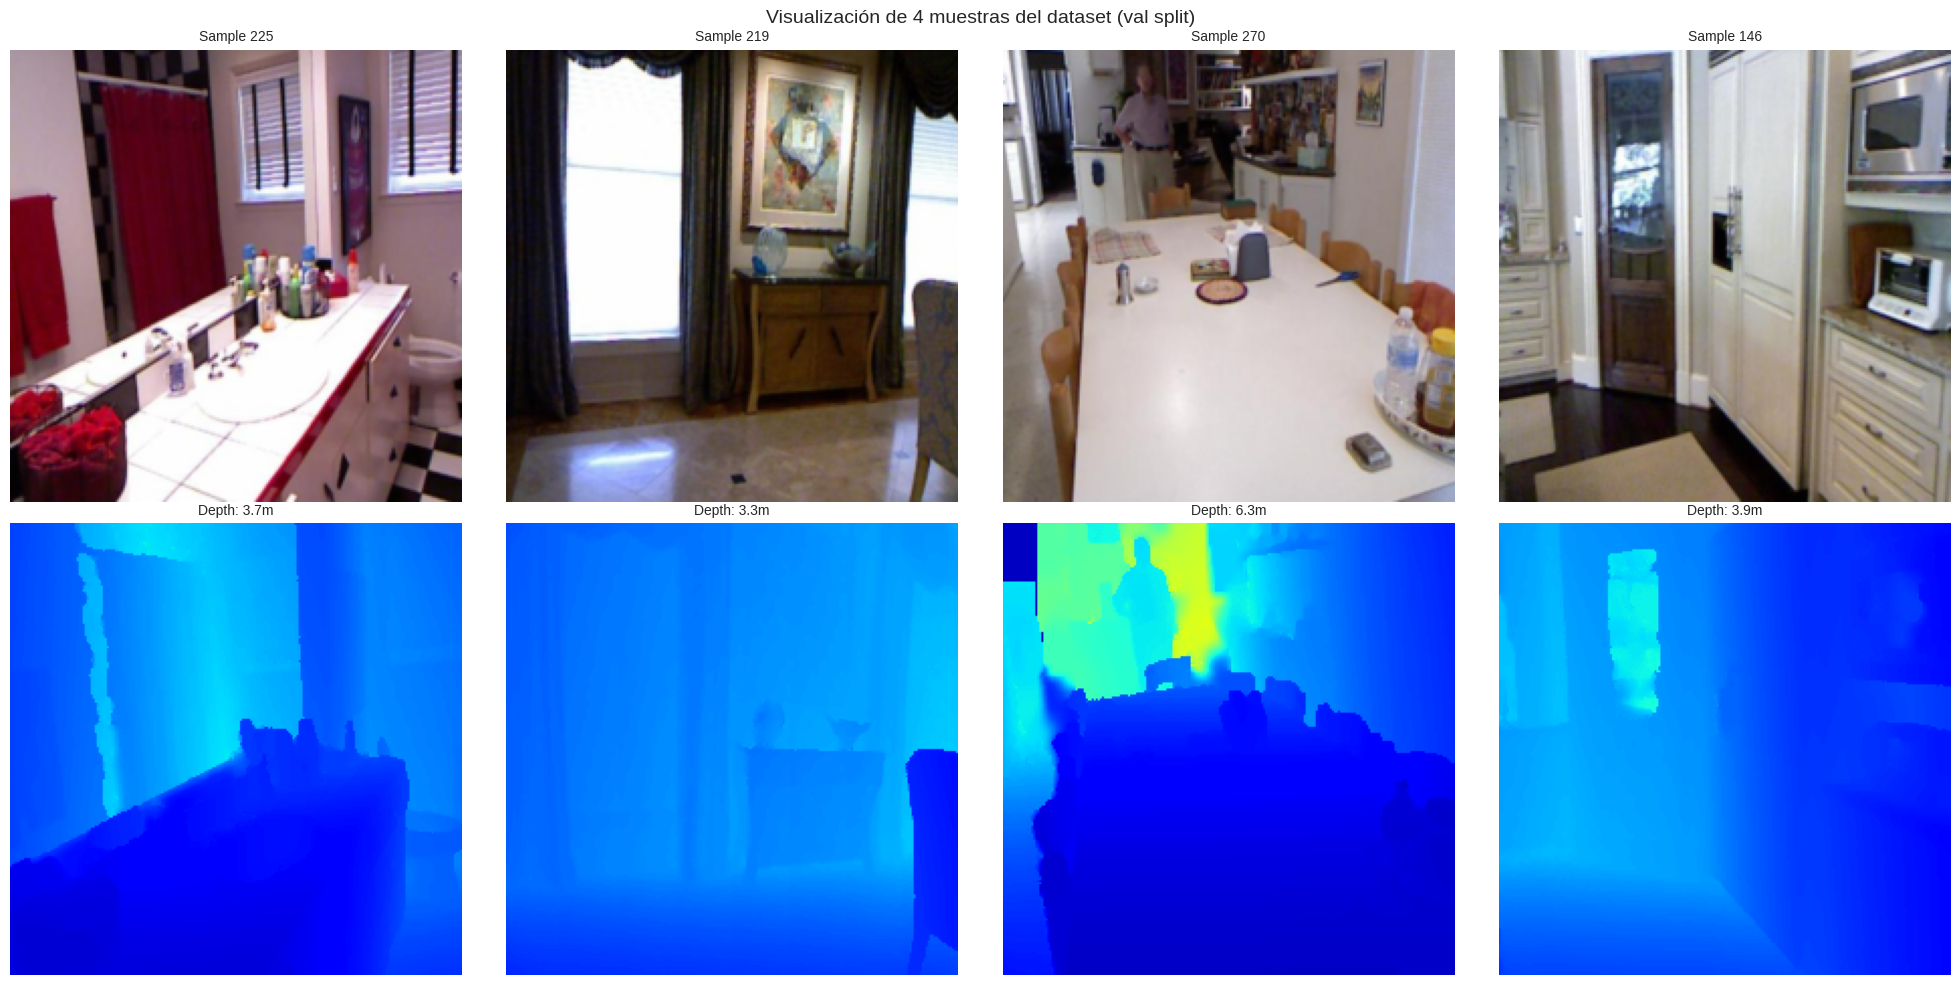

In [22]:
def test_sunnyu_visualizations(dataset_path="SUNRGBD/kv1", split="train", augment=True):
    """
    Función principal para probar todas las visualizaciones con SUNNYUFolderDataset.
    """
    print("="*60)
    print(f"PROBANDO VISUALIZACIONES CON SUNNYUFolderDataset")
    print(f"Dataset: {dataset_path}")
    print(f"Split: {split}, Augment: {augment}")
    print("="*60)
    
    # Crear dataset
    dataset = SUNNYUFolderDataset(
        root_dir=dataset_path,
        split=split,
        resize=(224, 224),
        augment=augment,
    )
    
    print(f"✓ Dataset creado: {len(dataset)} muestras en split '{split}'")
    
    # Obtener una muestra
    idx = random.randint(0, len(dataset) - 1)
    sample = dataset[idx]
    
    print(f"\n1. VISUALIZANDO MUESTRA ALEATORIA (índice {idx}):")
    visualize_sample(sample, dataset=dataset)
    
    print(f"\n2. VISUALIZACIÓN CON OVERLAY RGB-DEPTH:")
    visualize_rgbd_overlay(sample, alpha=0.6)
    
    print(f"\n3. VISUALIZANDO {min(6, len(dataset))} MUESTRAS ALEATORIAS:")
    visualize_dataset_grid(dataset, num_samples=6)
    
    # Solo mostrar comparación de augmentación si estamos en train
    if split == 'train' and augment:
        print(f"\n4. COMPARACIÓN DE AUGMENTACIONES:")
        visualize_augmentation_comparison(dataset, num_pairs=3)
    
    print(f"\n5. ESTADÍSTICAS DEL DATASET:")
    visualize_dataset_stats(dataset, max_samples=1000)
    
    return dataset

# Ejemplo de uso
if __name__ == "__main__":
    # Configurar estilo
    plt.style.use('seaborn-v0_8-darkgrid')
    
    # Probar con dataset de entrenamiento (con augmentación)
    dataset_train = test_sunnyu_visualizations(
        dataset_path="SUNRGBD/kv1",
        split="train",
        augment=True
    )
    
    # Probar con dataset de validación (sin augmentación)
    print("\n" + "="*60)
    print("PROBANDO SPLIT DE VALIDACIÓN")
    print("="*60)
    
    dataset_val = SUNNYUFolderDataset(
        root_dir="SUNRGBD/kv1",
        split="val",
        augment=False
    )
    
    # Visualizar algunas muestras de validación
    print(f"Dataset de validación: {len(dataset_val)} muestras")
    visualize_dataset_grid(dataset_val, num_samples=4)

In [23]:
def debug_augmentation(dataset, idx=0, num_iterations=5):
    """
    Muestra múltiples augmentaciones de la misma imagen para debugging.
    """
    if dataset.split != 'train' or not dataset.augment:
        print("Dataset no está en modo augmentación")
        return
    
    item = dataset.samples[idx]
    print(f"Debugging augmentaciones para muestra {idx}:")
    print(f"  RGB: {item['rgb_path']}")
    print(f"  Depth: {item['depth_path']}")
    
    fig, axes = plt.subplots(2, num_iterations, figsize=(20, 8))
    
    for i in range(num_iterations):
        # Obtener muestra aumentada
        sample = dataset[idx]
        
        # Convertir a numpy
        rgb_np = np.transpose(sample['rgb'].numpy(), (1, 2, 0))
        depth_np = sample['depth'].numpy().squeeze()
        
        # Mostrar
        axes[0, i].imshow(rgb_np)
        axes[0, i].set_title(f"Iteración {i+1}")
        axes[0, i].axis('off')
        
        axes[1, i].imshow(depth_np, cmap='jet', vmin=0, vmax=10)
        axes[1, i].axis('off')
    
    plt.suptitle(f"Variaciones de augmentación para muestra {idx}", fontsize=16)
    plt.tight_layout()
    plt.show()

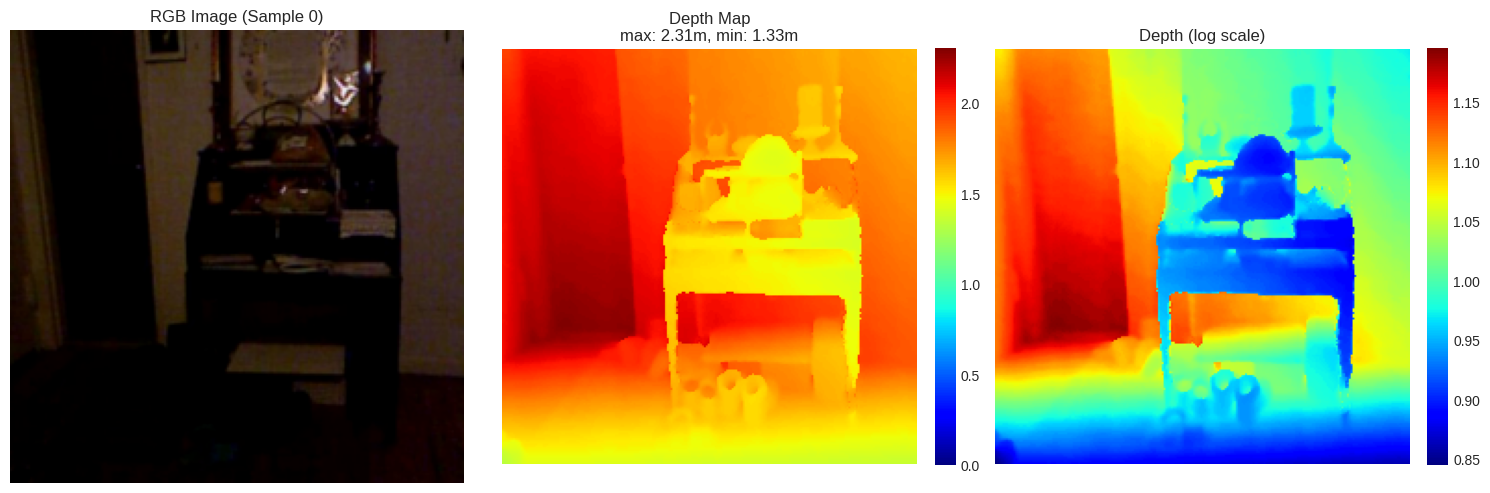


=== Estadísticas de la muestra 0 ===
RGB shape: torch.Size([3, 224, 224]), range: [0.000, 0.941]
Depth shape: torch.Size([1, 224, 224])
Depth range: [1.328, 2.306] m
Depth mean: 1.812 m, std: 0.242 m

Paths:
  RGB: SUNRGBD/kv1/NYUdata/NYU0154/image/NYU0154.jpg
  Depth: SUNRGBD/kv1/NYUdata/NYU0154/depth_bfx/NYU0154.png
  Scene: NYU0154
Debugging augmentaciones para muestra 0:
  RGB: SUNRGBD/kv1/NYUdata/NYU0154/image/NYU0154.jpg
  Depth: SUNRGBD/kv1/NYUdata/NYU0154/depth_bfx/NYU0154.png


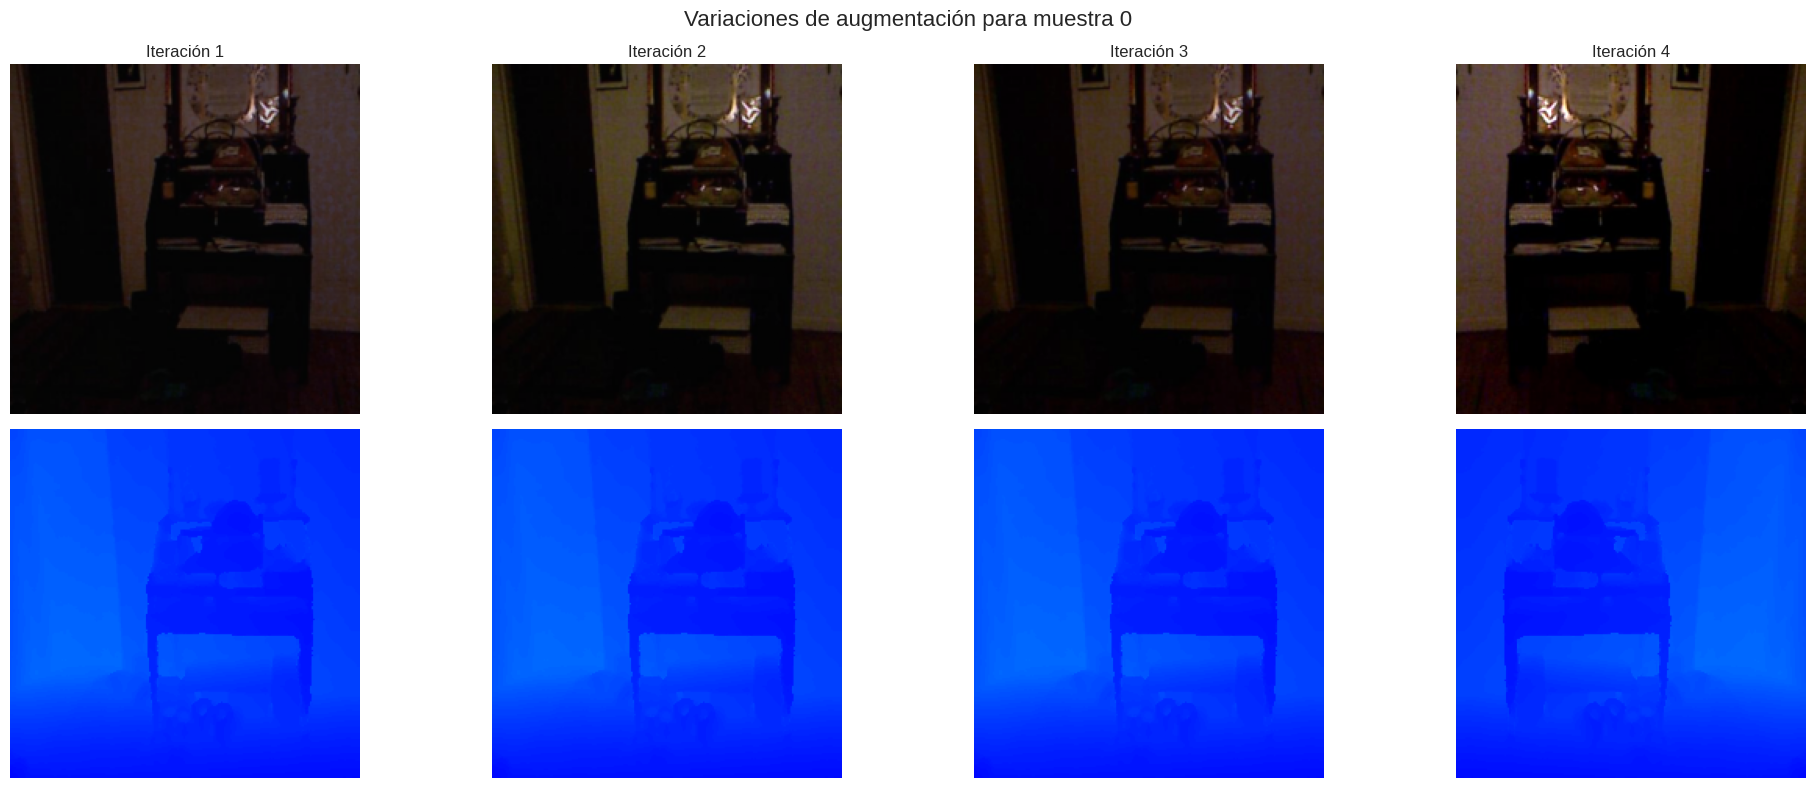

Analizando estadísticas del dataset (train split)...
  Procesado 0/1403 muestras...


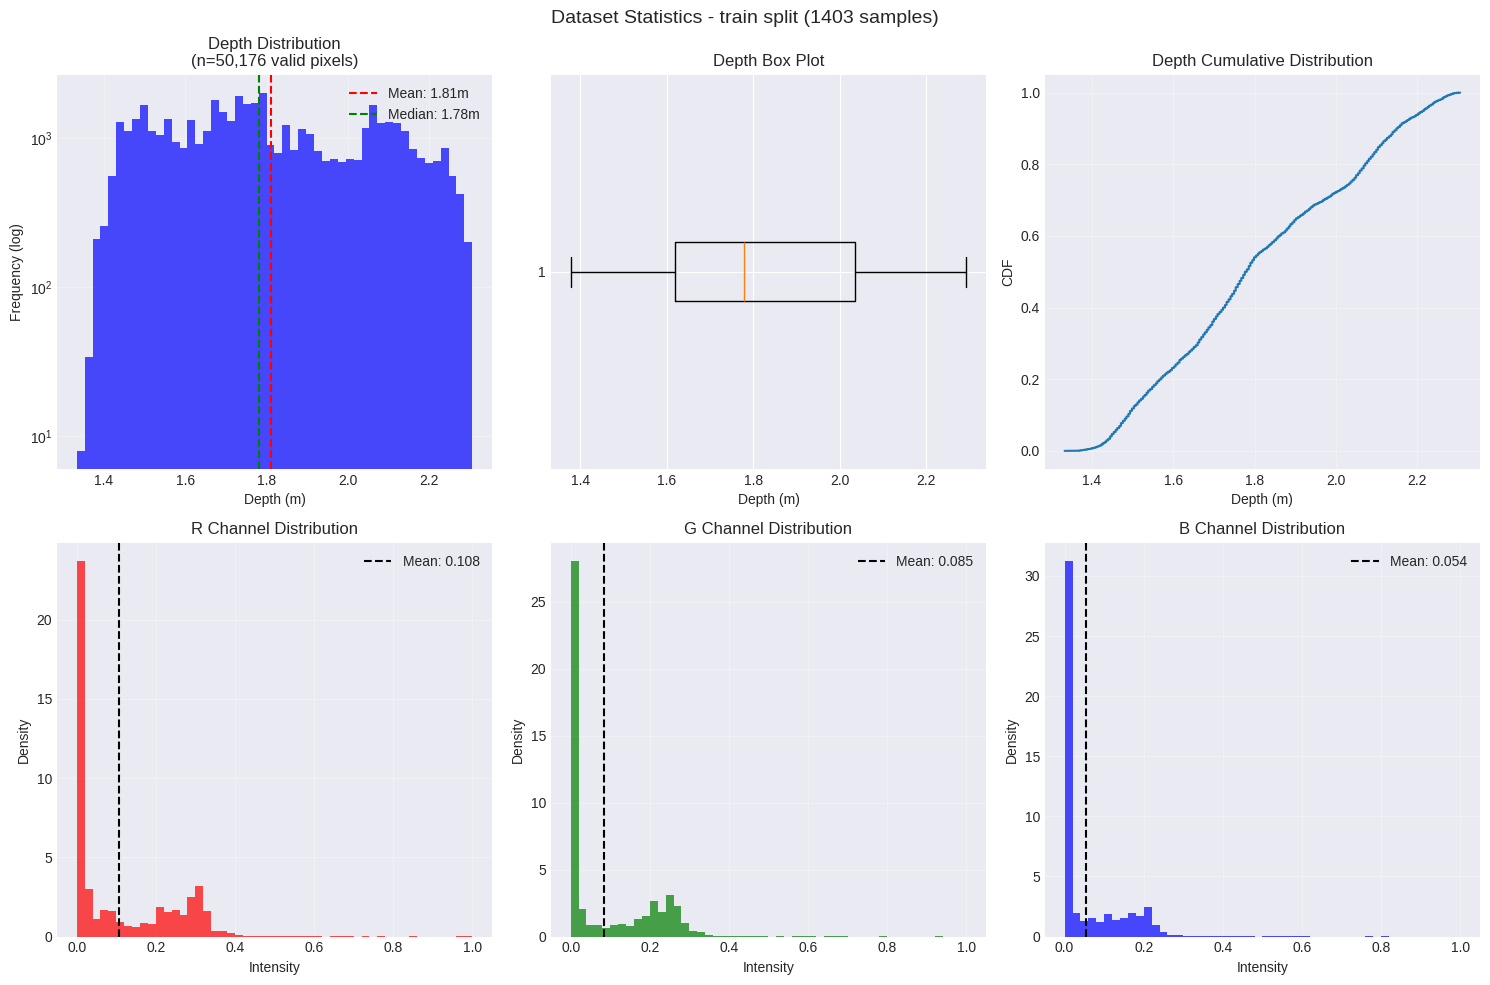


ESTADÍSTICAS DEL DATASET (TRAIN)
Número de muestras: 1403
Píxeles válidos analizados: 50,176

Profundidad:
  Min: 1.333 m
  Max: 2.306 m
  Mean: 1.812 ± 0.242 m
  Median: 1.781 m
  25th percentile: 1.615 m
  75th percentile: 2.036 m
  90th percentile: 2.149 m

RGB (rango [0, 1]):
  R: mean=0.108, std=0.132, min=0.000, max=1.000
  G: mean=0.085, std=0.115, min=0.000, max=1.000
  B: mean=0.054, std=0.086, min=0.000, max=1.000


In [25]:
# Importar
import matplotlib.pyplot as plt
import numpy as np
import random

# Configurar
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['image.cmap'] = 'jet'

# 1. Crear dataset
dataset = SUNNYUFolderDataset(
    root_dir="SUNRGBD/kv1",
    split="train",
    augment=True
)

# 2. Visualizar una muestra
sample = dataset[0]
visualize_sample(sample, dataset=dataset)

# 3. Ver augmentaciones
debug_augmentation(dataset, idx=0, num_iterations=4)

# 4. Ver estadísticas
visualize_dataset_stats(dataset)